# Model Comparison — 5 Embedding Models on Greek Workplace Documents

Loads FAISS metadata from all 5 indexes and compares: dimensions, chunk counts, index sizes, build dates.

**Run with:** `$VENV_GTE -m jupyter notebook`

In [2]:
import json, os
import numpy as np

FAISS_BASE = '$FAISS_BASE'
MODELS = ['cohere-v3', 'e5-base', 'e5-large', 'gte', 'bge-m3']

# Load metadata from all indexes
data = []
for m in MODELS:
    meta_path = f'{FAISS_BASE}/{m}/metadata.json'
    idx_path = f'{FAISS_BASE}/{m}/index.faiss'
    if os.path.exists(meta_path):
        meta = json.load(open(meta_path))
        idx_size = os.path.getsize(idx_path) / 1e6 if os.path.exists(idx_path) else 0
        data.append({
            'Model': m,
            'Full Name': meta.get('model', '?'),
            'Dim': meta.get('dim', '?'),
            'Docs': meta.get('num_docs', len(meta.get('doc_paths', []))),
            'Chunks': meta.get('num_chunks', len(meta.get('chunk_doc_ids', []))),
            'Index MB': round(idx_size, 1),
            'Built': meta.get('build_time', '?'),
        })

print(f'Loaded {len(data)} models')

Loaded 5 models


In [5]:
# Display comparison table
try:
    import pandas as pd
    df = pd.DataFrame(data)
    
    # Color-code by ranking (manual ranking from experiments)
    ranking_colors = {
        'cohere-v3': '#4CAF50',   # green — best
        'e5-base':   '#2196F3',   # blue
        'e5-large':  '#2196F3',   # blue
        'gte':       '#FF9800',   # orange
        'bge-m3':    '#F44336',   # red — worst
    }
    
    def color_row(row):
        color = ranking_colors.get(row['Model'], '')
        return [f'background-color: {color}'] * len(row)
    
    styled = df.style.apply(color_row, axis=1).set_caption(
        'FAISS Index Comparison — ranked by Greek workplace doc performance'
    )
    display(styled)
except ImportError:
    for row in data:
        print(row)


,Model,Full Name,Dim,Docs,Chunks,Index MB,Built
0,cohere-v3,cohere/embed-multilingual-v3.0,1024,5707,80568,330.000000,2026-03-29
1,e5-base,intfloat/multilingual-e5-base,768,8304,84597,259.900000,2026-03-28 08:15:17
2,e5-large,intfloat/multilingual-e5-large,1024,5707,80568,330.000000,2026-03-29
3,gte,Alibaba-NLP/gte-multilingual-base,768,8304,84597,259.900000,2026-03-28 16:44:50
4,bge-m3,BAAI/bge-m3,1024,5707,80568,330.000000,2026-03-29


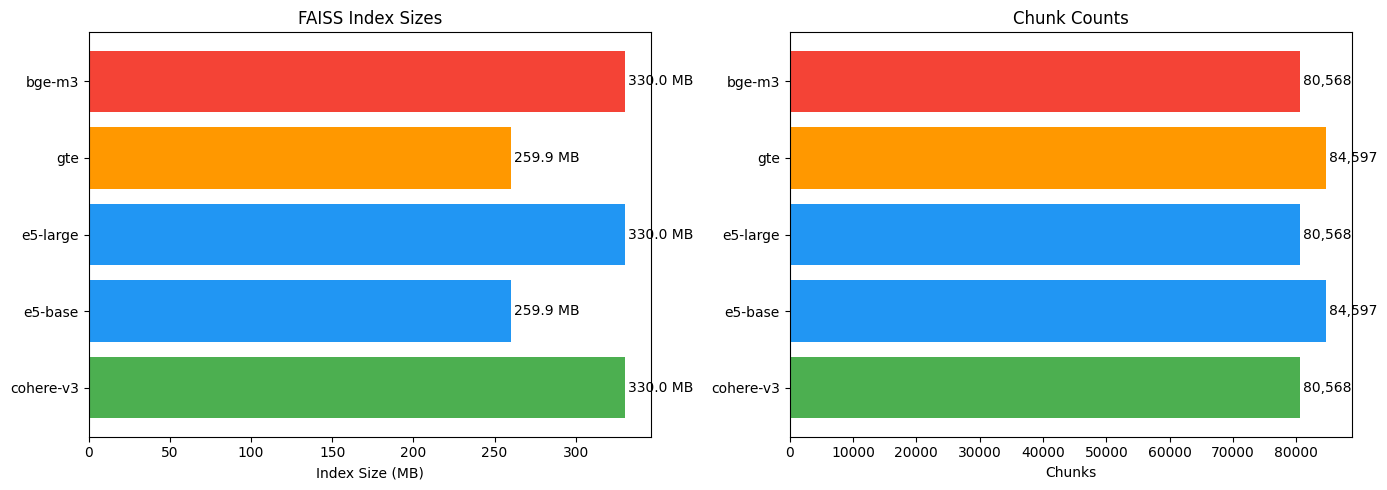

Saved: model_comparison.png


In [6]:
# Bar chart: Index sizes and chunk counts
try:
    import matplotlib.pyplot as plt
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    models = [d['Model'] for d in data]
    colors = ['#4CAF50', '#2196F3', '#2196F3', '#FF9800', '#F44336']
    
    # Index sizes
    sizes = [d['Index MB'] for d in data]
    ax1.barh(models, sizes, color=colors)
    ax1.set_xlabel('Index Size (MB)')
    ax1.set_title('FAISS Index Sizes')
    for i, v in enumerate(sizes):
        ax1.text(v + 2, i, f'{v} MB', va='center')
    
    # Chunk counts
    chunks = [d['Chunks'] for d in data]
    ax2.barh(models, chunks, color=colors)
    ax2.set_xlabel('Chunks')
    ax2.set_title('Chunk Counts')
    for i, v in enumerate(chunks):
        ax2.text(v + 500, i, f'{v:,}', va='center')
    
    plt.tight_layout()
    plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: model_comparison.png')
except ImportError:
    print('matplotlib not installed — skip chart')

## Model Ranking (from real-query testing)

| Rank | Model | Strength | Weakness |
|------|-------|----------|----------|
| 1 | **Cohere v3** | Best Greek precision, no English tech noise | API-only, ~$1.60/index |
| 2 | e5-base | Good retrieval asymmetry, found emails others missed | Scores cluster 0.83-0.88 |
| 3 | e5-large | Broadest coverage for legal docs | Slower, more VRAM |
| 4 | GTE | Sharpest discrimination, 8K context | Confused by SCADA/OCR noise |
| 5 | bge-m3 | Strong MTEB benchmarks | Worst on real Greek queries |

**Key finding:** No single model finds everything. Each contributes unique relevant files.